In [64]:
%pip install numpy pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [65]:
# Data handling
import numpy as np
import pandas as pd

# Visualization and exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Regression models and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR


from sklearn.impute import KNNImputer

# Regression evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

In [66]:
df = pd.read_csv("crop_yield_dataset.csv")
print("Data loaded successfully. Here's a preview:")
df.head()
print("\nData summary:")
df.describe()

Data loaded successfully. Here's a preview:

Data summary:


,Rainfall_mm,Temperature_C,Soil_pH,Fertilizer_kg_per_ha,Pesticide_kg_per_ha,Sunlight_Hours_per_day,Farm_Size_ha,Crop_Yield_tonnes_per_ha
count,9995.000,10083.000,10091.000,9882.000,10013.000,10222.000,9996.000,10515.000
mean,910.446,24.036,6.504,149.494,5.017,7.480,5.372,8.135
std,255.016,5.037,0.810,60.756,2.452,1.518,17.083,1.451
min,100.000,5.000,3.680,0.000,0.000,2.200,0.200,4.270
25%,740.650,20.600,5.960,109.600,3.320,6.500,1.790,7.110
50%,908.800,24.000,6.500,148.900,4.960,7.500,3.280,7.960
75%,1076.500,27.400,7.050,189.275,6.690,8.500,6.062,9.040
max,3922.262,44.400,9.400,713.711,15.070,12.000,774.900,13.130


In [67]:
print("Displaying data types and non-null counts:")
df.info()

Displaying data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 10515 entries, 0 to 10514
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Soil_Type                 10184 non-null  str    
 1   Crop_Type                 10275 non-null  str    
 2   Rainfall_mm               9995 non-null   float64
 3   Temperature_C             10083 non-null  float64
 4   Soil_pH                   10091 non-null  float64
 5   Fertilizer_kg_per_ha      9882 non-null   float64
 6   Pesticide_kg_per_ha       10013 non-null  float64
 7   Sunlight_Hours_per_day    10222 non-null  float64
 8   Farm_Size_ha              9996 non-null   float64
 9   Irrigation                10204 non-null  str    
 10  Crop_Yield_tonnes_per_ha  10515 non-null  float64
dtypes: float64(8), str(3)
memory usage: 903.8 KB


In [68]:
print("\nChecking for missing values:")
print(df.isnull().sum())


Checking for missing values:
Soil_Type                   331
Crop_Type                   240
Rainfall_mm                 520
Temperature_C               432
Soil_pH                     424
Fertilizer_kg_per_ha        633
Pesticide_kg_per_ha         502
Sunlight_Hours_per_day      293
Farm_Size_ha                519
Irrigation                  311
Crop_Yield_tonnes_per_ha      0
dtype: int64


In [69]:
print("Checking for duplicate rows:")
print(df.duplicated().sum())

Checking for duplicate rows:
15


In [70]:
print("\n Checking for categorical variables:")
for col in df.columns:
    if df[col].dtype == 'str':
        print(f"{col}: {df[col].nunique()} unique values")



 Checking for categorical variables:
Soil_Type: 5 unique values
Crop_Type: 6 unique values
Irrigation: 2 unique values


In [71]:
print("\nUnique values in categorical columns:")
for col in df.columns:
    # Pandas usually stores strings as 'object' or 'string' type
    if df[col].dtype == "object" or df[col].dtype == "string":
        print()
        print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")



Unique values in categorical columns:

Soil_Type: 5 unique values -> <StringArray>
['Peaty', 'Clay', 'Silty', 'Sandy', 'Loamy', nan]
Length: 6, dtype: str

Crop_Type: 6 unique values -> <StringArray>
['Soybean', 'Wheat', 'Rice', 'Cotton', 'Barley', 'Maize', nan]
Length: 7, dtype: str

Irrigation: 2 unique values -> <StringArray>
['Yes', 'No', nan]
Length: 3, dtype: str


In [72]:
print("\nChecking for numerical variables:")
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(f"{col}: {df[col].describe()}")
        print()


Checking for numerical variables:
Rainfall_mm: count   9995.000
mean     910.446
std      255.016
min      100.000
25%      740.650
50%      908.800
75%     1076.500
max     3922.262
Name: Rainfall_mm, dtype: float64

Temperature_C: count   10083.000
mean       24.036
std         5.037
min         5.000
25%        20.600
50%        24.000
75%        27.400
max        44.400
Name: Temperature_C, dtype: float64

Soil_pH: count   10091.000
mean        6.504
std         0.810
min         3.680
25%         5.960
50%         6.500
75%         7.050
max         9.400
Name: Soil_pH, dtype: float64

Fertilizer_kg_per_ha: count   9882.000
mean     149.494
std       60.756
min        0.000
25%      109.600
50%      148.900
75%      189.275
max      713.711
Name: Fertilizer_kg_per_ha, dtype: float64

Pesticide_kg_per_ha: count   10013.000
mean        5.017
std         2.452
min         0.000
25%         3.320
50%         4.960
75%         6.690
max        15.070
Name: Pesticide_kg_per_ha, dtype: 

In [73]:
print("\n Checking for outliers using IQR method:")
no_of_outliers = 0
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
        print(f"{col}: {len(outliers)} outliers")
        #print(f"{col} outliers: {outliers}")
        print()
        print()
        no_of_outliers += len(outliers)


 Checking for outliers using IQR method:
Rainfall_mm: 65 outliers


Temperature_C: 75 outliers


Soil_pH: 75 outliers


Fertilizer_kg_per_ha: 34 outliers


Pesticide_kg_per_ha: 43 outliers


Sunlight_Hours_per_day: 74 outliers


Farm_Size_ha: 735 outliers


Crop_Yield_tonnes_per_ha: 49 outliers




Box plots for numerical variables:


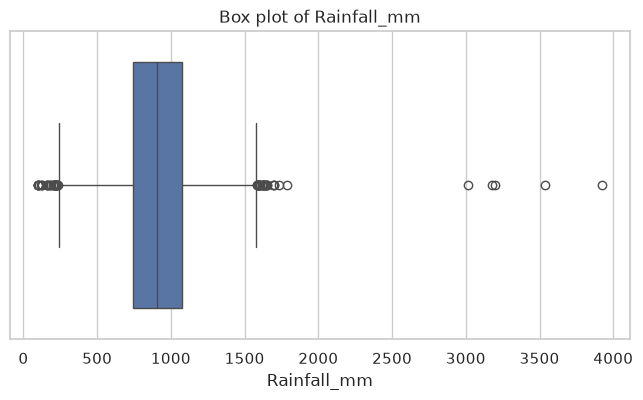

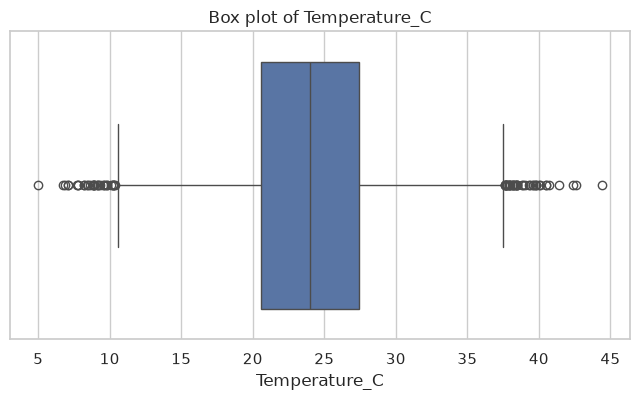

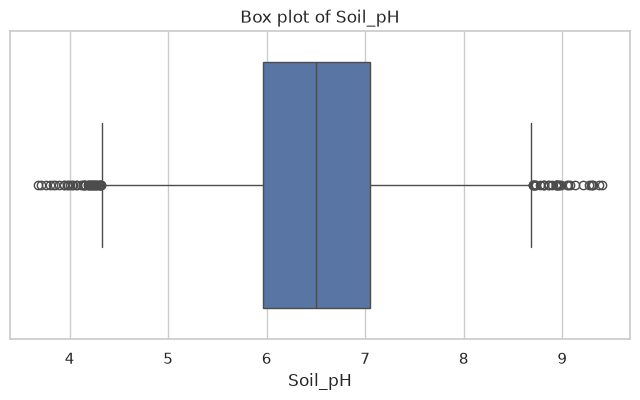

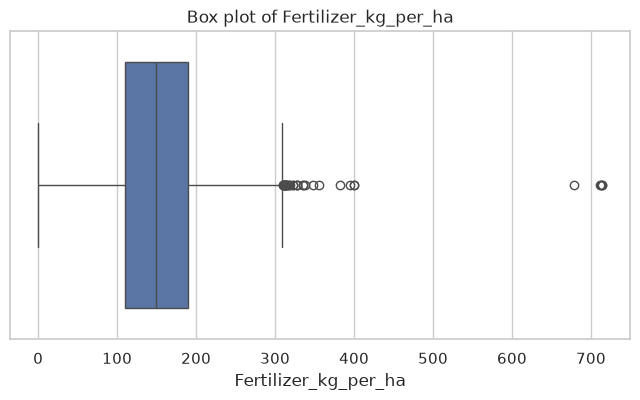

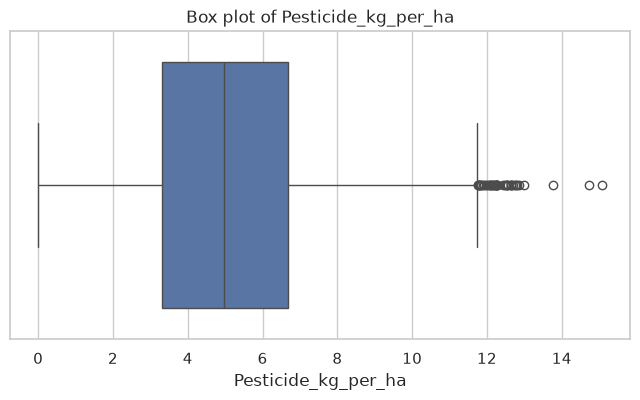

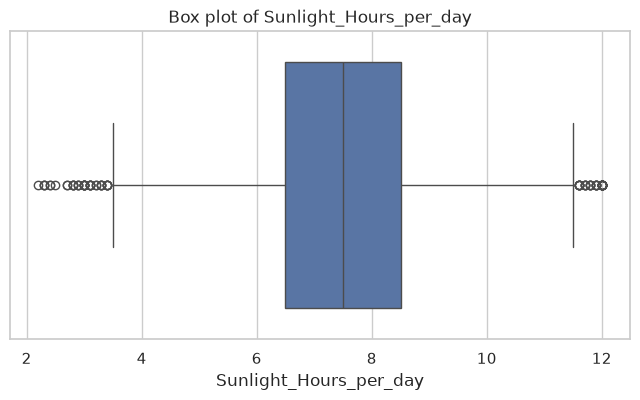

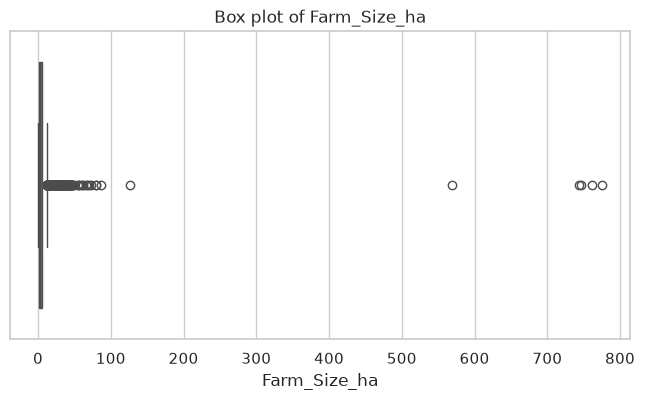

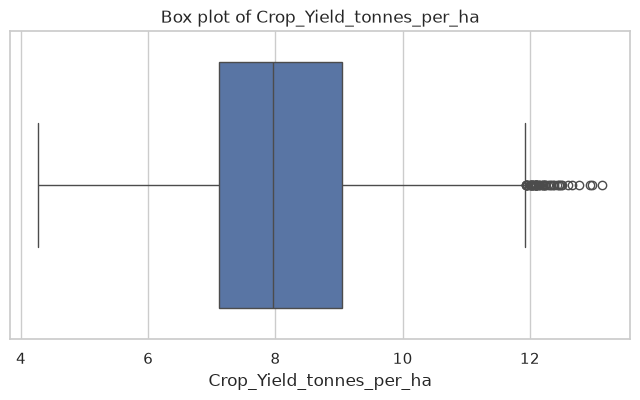

In [74]:
print("Box plots for numerical variables:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')

In [75]:
print("Data summary :")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Categorical columns: {len(df.select_dtypes(include=['object', 'string']).columns)}")
print(f"Numerical columns: {len(df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Total outliers detected: {no_of_outliers}")
print(f"Total unique values in categorical columns: {sum(df[col].nunique() for col in df.select_dtypes(include=['object', 'string']).columns)}")
print(f"Total unique values in numerical columns: {sum(df[col].nunique() for col in df.select_dtypes(include=['int64', 'float64']).columns)}")

Data summary :
Rows: 10515, Columns: 11
Missing values: 4205
Duplicate rows: 15
Categorical columns: 3
Numerical columns: 8
Total outliers detected: 1150
Total unique values in categorical columns: 13
Total unique values in numerical columns: 13231


In [76]:
print("Capping all the outliers in the dataset with the 1st and 99th percentiles:")
for col in numerical_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    print(f"Column {col}: Lower bound = {lower_bound}, Upper bound = {upper_bound}")

print("Capping of outliers completed successfully.")
print("Data after capping outliers:")
print(df.head())


Capping all the outliers in the dataset with the 1st and 99th percentiles:
Column Rainfall_mm: Lower bound = 330.164, Upper bound = 1488.4299999999998
Column Temperature_C: Lower bound = 12.4, Upper bound = 35.9
Column Soil_pH: Lower bound = 4.59, Upper bound = 8.42
Column Fertilizer_kg_per_ha: Lower bound = 7.624000000000001, Upper bound = 286.7380000000001
Column Pesticide_kg_per_ha: Lower bound = 0.0, Upper bound = 10.857599999999984
Column Sunlight_Hours_per_day: Lower bound = 4.0, Upper bound = 11.0
Column Farm_Size_ha: Lower bound = 0.42, Upper bound = 28.908999999999867
Column Crop_Yield_tonnes_per_ha: Lower bound = 5.2514, Upper bound = 11.578600000000005
Capping of outliers completed successfully.
Data after capping outliers:
  Soil_Type Crop_Type  Rainfall_mm  Temperature_C  Soil_pH  \
0     Peaty   Soybean      633.700         22.700    6.000   
1     Peaty     Wheat          NaN         23.900    6.050   
2     Peaty      Rice      423.600         17.400    5.770   
3      

In [77]:
print("Using KNN Imputer to fill missing values in the dataset:")
knn_imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = knn_imputer.fit_transform(df[numerical_cols])
print("KNN Imputation completed successfully.")


Using KNN Imputer to fill missing values in the dataset:


KNN Imputation completed successfully.


In [78]:
print("Missing values after KNN Imputation: ", df.isnull().sum())


Missing values after KNN Imputation:  Soil_Type                   331
Crop_Type                   240
Rainfall_mm                   0
Temperature_C                 0
Soil_pH                       0
Fertilizer_kg_per_ha          0
Pesticide_kg_per_ha           0
Sunlight_Hours_per_day        0
Farm_Size_ha                  0
Irrigation                  311
Crop_Yield_tonnes_per_ha      0
dtype: int64


In [79]:
df['Crop_Type']

0        Soybean
1          Wheat
2           Rice
3           Rice
4          Wheat
          ...   
10510       Rice
10511    Soybean
10512     Barley
10513      Wheat
10514    Soybean
Name: Crop_Type, Length: 10515, dtype: str

In [80]:
print("Deleting all the missing categorical values")
df = df.dropna(subset=["Irrigation","Crop_Type"])
print("Missing values after deleting missing categorical values: ", df.isnull().sum())

Deleting all the missing categorical values
Missing values after deleting missing categorical values:  Soil_Type                   308
Crop_Type                     0
Rainfall_mm                   0
Temperature_C                 0
Soil_pH                       0
Fertilizer_kg_per_ha          0
Pesticide_kg_per_ha           0
Sunlight_Hours_per_day        0
Farm_Size_ha                  0
Irrigation                    0
Crop_Yield_tonnes_per_ha      0
dtype: int64


In [81]:
df.head()


,Soil_Type,Crop_Type,Rainfall_mm,Temperature_C,Soil_pH,Fertilizer_kg_per_ha,Pesticide_kg_per_ha,Sunlight_Hours_per_day,Farm_Size_ha,Irrigation,Crop_Yield_tonnes_per_ha
0,Peaty,Soybean,633.700,22.700,6.000,137.200,4.150,7.400,3.360,Yes,8.160
1,Peaty,Wheat,1068.540,23.900,6.050,50.800,4.180,11.000,7.108,No,6.560
2,Peaty,Rice,423.600,17.400,5.770,247.400,7.450,9.000,1.320,No,8.340
3,Clay,Rice,965.200,27.200,5.850,97.400,4.050,8.200,4.300,No,7.840
4,Peaty,Wheat,1056.700,27.300,5.550,252.000,7.760,6.900,1.340,Yes,8.220


In [82]:
duplicate_rows = df[df.duplicated()]
if not duplicate_rows.empty:
    print(f"{len(duplicate_rows)} Duplicate rows found")
    #print(duplicate_rows)
    # Optionally, you can drop the duplicate rows
    df = df.drop_duplicates()
print("Duplicate rows after dropping duplicates: ", df.duplicated().sum())


14 Duplicate rows found
Duplicate rows after dropping duplicates:  0


In [83]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

In [84]:
#One hot encoding for categorical variables
df = pd.get_dummies(df, columns=categorical_cols, dtype=int,drop_first=True)
print("Data after one-hot encoding:")
print(df.head())



Data after one-hot encoding:
   Rainfall_mm  Temperature_C  Soil_pH  Fertilizer_kg_per_ha  \
0      633.700         22.700    6.000               137.200   
1     1068.540         23.900    6.050                50.800   
2      423.600         17.400    5.770               247.400   
3      965.200         27.200    5.850                97.400   
4     1056.700         27.300    5.550               252.000   

   Pesticide_kg_per_ha  Sunlight_Hours_per_day  Farm_Size_ha  \
0                4.150                   7.400         3.360   
1                4.180                  11.000         7.108   
2                7.450                   9.000         1.320   
3                4.050                   8.200         4.300   
4                7.760                   6.900         1.340   

   Crop_Yield_tonnes_per_ha  Soil_Type_Loamy  Soil_Type_Peaty  \
0                     8.160                0                1   
1                     6.560                0                1   
2     